## How can we develop a Deep Learning-based CNN model that can automatically classify images as fire or no fire to help in early fire detection and safety monitoring?

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen=ImageDataGenerator(rescale=1./255,validation_split=0.3)

In [4]:
train_generator = datagen.flow_from_directory('Datasets/fire_dataset/',target_size=(64,64),class_mode='binary',subset='training')
test_generator = datagen.flow_from_directory('Datasets/fire_dataset/',target_size=(64,64),class_mode='binary',subset='validation')

Found 703 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [5]:
train_generator

In [6]:
data,label=next(train_generator)
data.shape

(32, 64, 64, 3)

### Display images

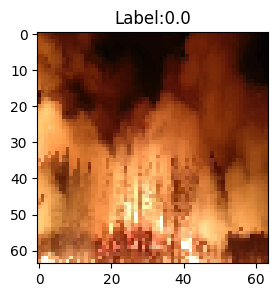

In [7]:
plt.figure(figsize=(3,3))
plt.imshow(data[2])
plt.title(f"Label:{label[2]}")
plt.show()                          ### fire:0, no_fire:1

### Convolution windows

In [8]:
cnn=tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation="relu",input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=128, activation="relu"))
cnn.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))

C:\Users\Prachi Inkane\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile

In [9]:
cnn.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [10]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

### feed data

In [11]:
result = cnn.fit(x = train_generator,validation_data=test_generator,epochs=5)      ## Training accuracy

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 642ms/step - accuracy: 0.8222 - loss: 0.4094 - val_accuracy: 0.9100 - val_loss: 0.2141
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 639ms/step - accuracy: 0.9289 - loss: 0.1991 - val_accuracy: 0.9633 - val_loss: 0.1476
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 610ms/step - accuracy: 0.9459 - loss: 0.1241 - val_accuracy: 0.9600 - val_loss: 0.1419
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 599ms/step - accuracy: 0.9431 - loss: 0.1274 - val_accuracy: 0.9433 - val_loss: 0.1392
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 553ms/step - accuracy: 0.9516 - loss: 0.0864 - val_accuracy: 0.9400 - val_loss: 0.1690


### test testing accuracy

In [12]:
cnn.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.9400 - loss: 0.1690


[0.16902315616607666, 0.9399999976158142]

### Deploy Model

In [13]:
#predict a new data
import numpy as np
from keras.preprocessing import image
from keras.utils import load_img
from keras.utils import img_to_array
new_image=load_img("DataSets/fire_dataset/single_prediction/no_fire3.jpg",target_size=(64,64))

# Convert the image object to array
new_image=img_to_array(new_image)
new_image= new_image/ 255.0
new_image=np.expand_dims(new_image, axis=0)
result=cnn.predict(new_image)
print(result)

# train_set.class_indices
if result[0][0]>=0.5:
  prediction = 'no fire'
else:
  prediction = 'fire'
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[0.9873559]]


'no fire'

In [14]:
cnn.save("fire_detection_model.h5")